<a href="https://colab.research.google.com/github/hatamimatt/ClimateDataScience/blob/main/era5SWVL1FloridaAnalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import xarray as xr
import gcsfs
import pandas as pd
from google.colab import files

# 1. Setup - Florida Bounding Box
fs = gcsfs.GCSFileSystem(token='anon')
LAT, LON = slice(31.2, 24.5), slice(272.0, 280.5)

# Generate a list of every single day from 2000 to April 2026
all_days = pd.date_range(start='2000-01-01', end='2026-04-20', freq='D')

def get_daily_map(d):
    path = f'gcp-public-data-arco-era5/raw/date-variable-single_level/{d.year}/{d.month:02d}/{d.day:02d}/volumetric_soil_water_layer_1/surface.nc'
    try:
        # Load the file and immediately select Florida + average the 24 hours
        ds = xr.open_dataset(fs.cat(path), engine='scipy')
        return ds.swvl1.sel(latitude=LAT, longitude=LON).mean('time')
    except: return None

# 2. Extract Data (Parallelized for speed)
from concurrent.futures import ThreadPoolExecutor
print(f"Extracting {len(all_days)} days of Florida soil moisture...")
with ThreadPoolExecutor(max_workers=30) as executor:
    daily_maps = list(executor.map(get_daily_map, all_days))

# 3. Clean, Resample to Monthly, and Export
# Filter out any failed days and combine into a time-series
ds_daily = xr.concat([m for m in daily_maps if m is not None], dim=all_days[:len([m for m in daily_maps if m is not None])])
ds_daily = ds_daily.rename({'concat_dim': 'time'})


ds_monthly = ds_daily.resample(time='MS').mean()

# 4. Save and Download
filename = "fl_soil_moisture_monthly_2000_2026.nc"
ds_monthly.to_netcdf(filename)
files.download(filename)

print("Process complete. File exported.")

Extracting 9607 days of Florida soil moisture...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Process complete. File exported.


/tmp/ipykernel_1603/2734835277.py:46: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0.05, 0.08, 0.95, 0.9]) # Adjust layout to make space for suptitle and colorbar


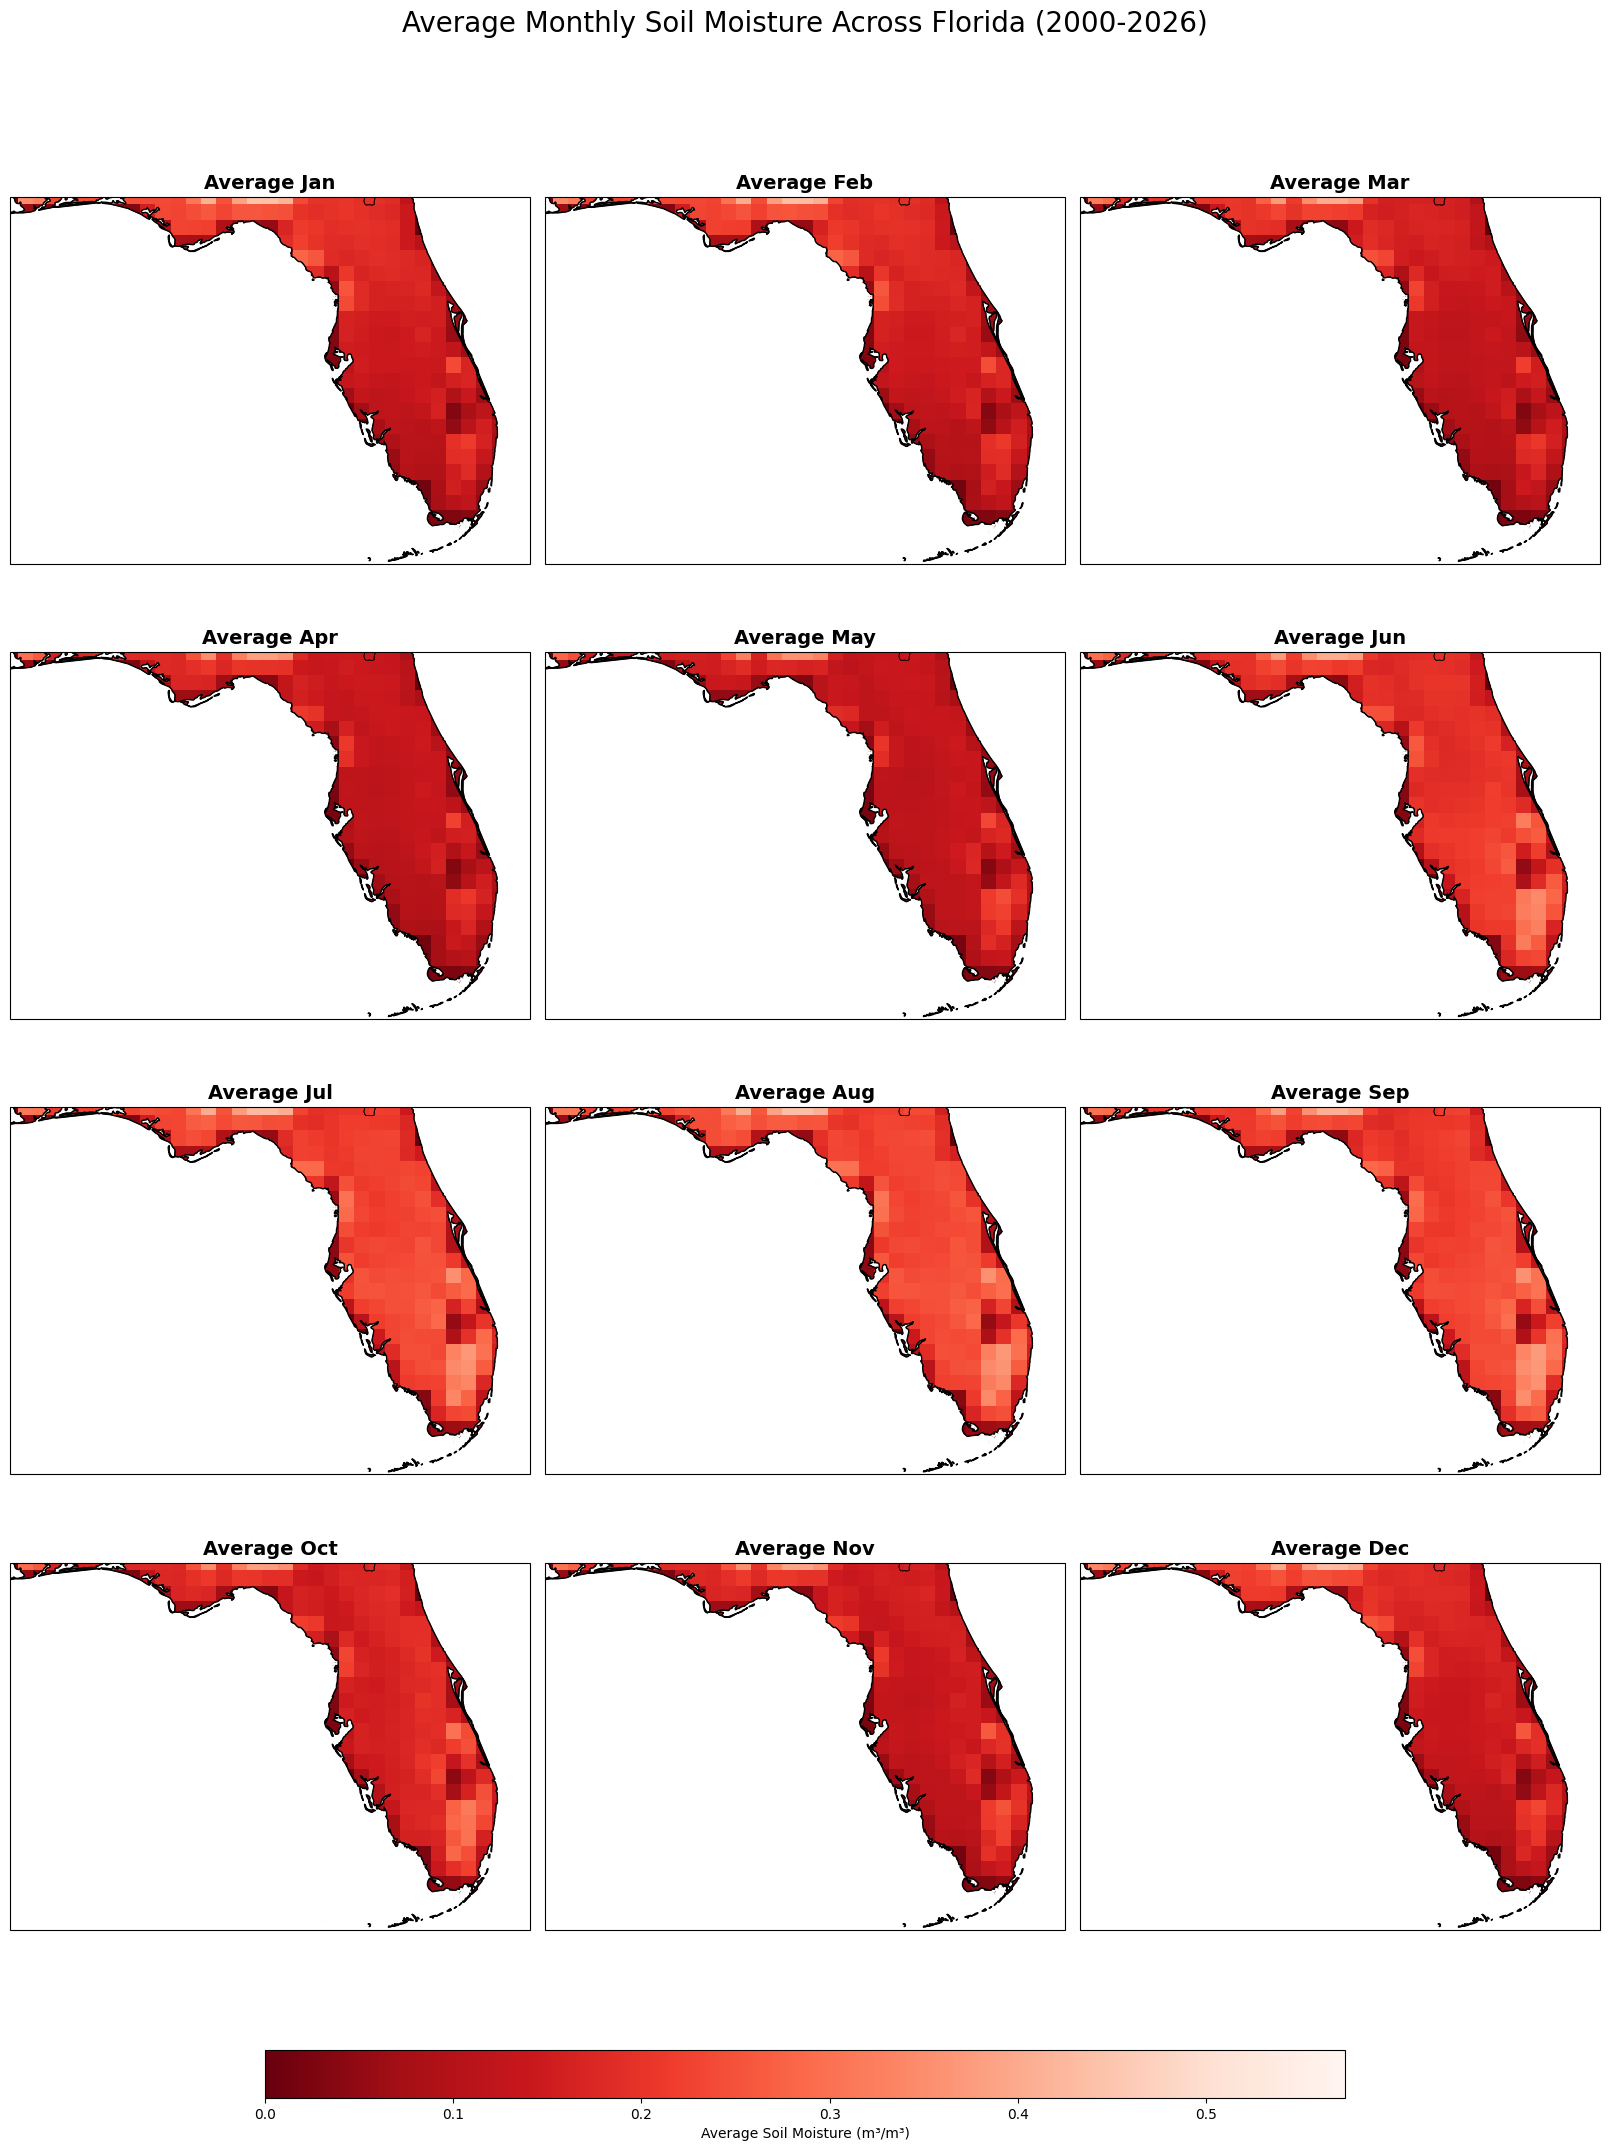

In [ ]:
import cartopy.feature as cfeature
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import calendar # To get month names

# Calculate the average soil moisture for each month across all years
monthly_avg_sm = ds.swvl1.groupby('time.month').mean('time')

# Define the common color scale for all plots for better comparison
vmin, vmax = monthly_avg_sm.min().item(), monthly_avg_sm.max().item()

# Create a 4x3 grid of subplots
fig, axes = plt.subplots(4, 3, figsize=(18, 24), subplot_kw={'projection': ccrs.PlateCarree()})
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

for i, month_num in enumerate(monthly_avg_sm['month'].values):
    ax = axes[i]
    month_data = monthly_avg_sm.sel(month=month_num)
    month_name = calendar.month_abbr[month_num]

    # Plot the monthly average soil moisture
    im = month_data.plot(
        ax=ax, transform=ccrs.PlateCarree(), cmap='Reds_r',
        vmin=vmin, vmax=vmax, add_colorbar=False # Colorbar will be added manually later
    )

    ax.set_title(f'Average {month_name}', fontsize=14, fontweight='bold')

    # Add geographic features
    ax.add_feature(cfeature.OCEAN, zorder=2, facecolor='white', edgecolor='none')
    ax.add_feature(cfeature.STATES, edgecolor='black', linewidth=0.5, zorder=3)
    ax.add_feature(cfeature.COASTLINE, zorder=3)
    ax.add_feature(cfeature.BORDERS, linestyle=':', zorder=3)

    # Set extent to Florida, removing 0.5 degrees from the northern border
    ax.set_extent([monthly_avg_sm.longitude.min().item(), monthly_avg_sm.longitude.max().item(),
                   monthly_avg_sm.latitude.min().item(), monthly_avg_sm.latitude.max().item() - 0.5])

# Add a unified colorbar for all subplots
cbar_ax = fig.add_axes([0.2, 0.05, 0.6, 0.02]) # [left, bottom, width, height]
fig.colorbar(im, cax=cbar_ax, orientation='horizontal', label='Average Soil Moisture (m³/m³)')

plt.suptitle('Average Monthly Soil Moisture Across Florida (2000-2026)', fontsize=20, y=0.92)
plt.tight_layout(rect=[0.05, 0.08, 0.95, 0.9]) # Adjust layout to make space for suptitle and colorbar
plt.show()

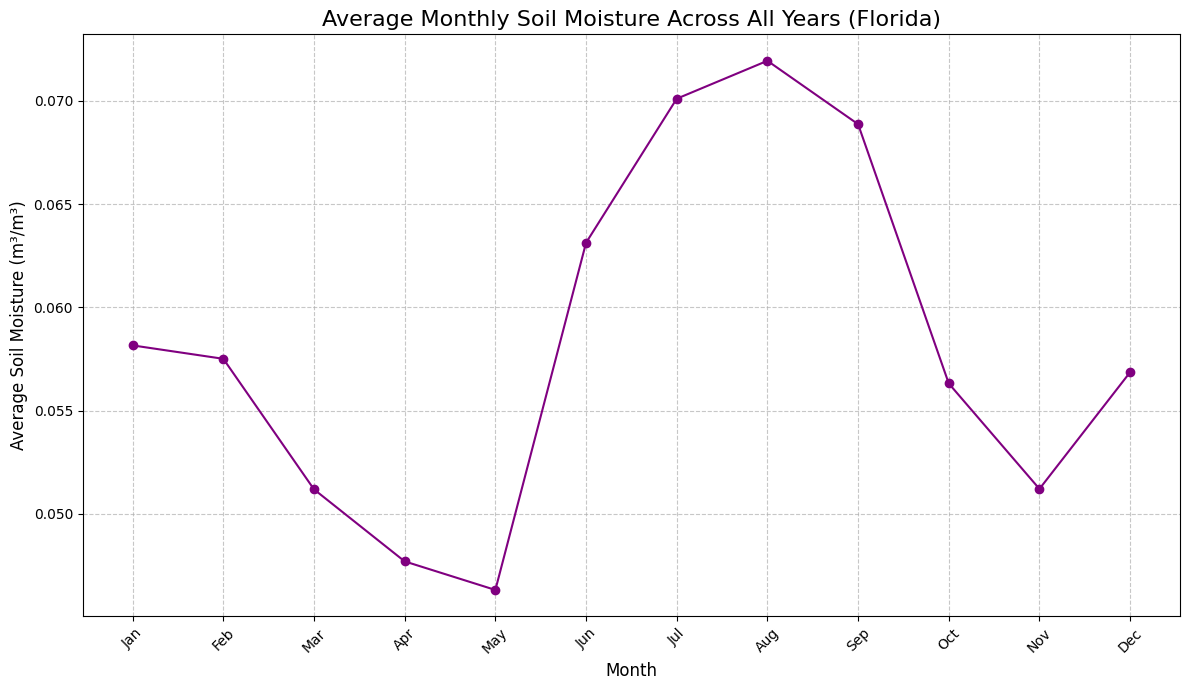

In [ ]:
import matplotlib.pyplot as plt
import calendar

# `monthly_avg_sm` is already calculated as ds.swvl1.groupby('time.month').mean('time')
# This gives the average soil moisture for each month across all years.

# Calculate the average soil moisture across latitude and longitude for each month
# and extract the values directly for plotting.
months = monthly_avg_sm['month'].values
avg_sm_values = monthly_avg_sm.mean(dim=['latitude', 'longitude']).values

# Map month numbers to month names for better readability
month_names = [calendar.month_abbr[m] for m in months]

plt.figure(figsize=(12, 7))
plt.plot(month_names, avg_sm_values, marker='o', linestyle='-', color='purple')
plt.title('Average Monthly Soil Moisture Across All Years (Florida)', fontsize=16)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Average Soil Moisture (m³/m³)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()